## Import

In [5]:
import pandas as pd # type: ignore
from datetime import datetime
from env import DiscreteEnv
import numpy as np # type: ignore
import matplotlib.pyplot as plt # type: ignore
from datetime import datetime
from stable_baselines3 import DQN
import seaborn as sns


In [14]:
df3 = pd.read_csv("../forecasters_replication/caiso_sp15_cnn3_forecast_nov2024-nov2025.csv", parse_dates=["datetime"], infer_datetime_format=True)
df3.rename(columns={"datetime": "Date"}, inplace=True)
split_index = int(len(df3) * 0.8)
train_df = df3.iloc[:split_index]
test_df = df3.iloc[split_index:]
df3.sample(5)

,Date,price,forecast_price_cnn3
7321,2025-09-23 21:00:00,51.314830,41.376675
6681,2025-08-28 05:00:00,36.376392,42.382526
2895,2025-03-23 11:00:00,-36.448060,-26.469150
5048,2025-06-21 04:00:00,27.895397,29.003340
1238,2025-01-13 10:00:00,10.686657,15.910932


## MlpLstmPolicy with perfect prices

### Train

In [16]:
# 3min
from sb3_contrib import RecurrentPPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
print("Initializing Training Environment...")

make_env = lambda: DiscreteEnv(len(train_df) - 100, train_df)
env = DummyVecEnv([make_env])
env = VecNormalize(env, norm_obs=True, norm_reward=True, clip_obs=10.)

print("Starting Training with RecurrentPPO...")

model = RecurrentPPO(
    "MlpLstmPolicy", 
    env, 
    verbose=1,
    learning_rate=3e-4,
    n_steps=2048,
    batch_size=64,
    n_epochs=10,
    gamma=0.99,
    gae_lambda=0.95,
    ent_coef=0.01,
    policy_kwargs={
        "net_arch": [],
        "enable_critic_lstm": True,
        "lstm_hidden_size": 256,
    }
)

model.learn(total_timesteps=20000)

model.save("ppo_recurrent_battery_wforecast")
env.save("vec_normalize_wforecast.pkl")

print("Training Complete.")

Initializing Training Environment...
Running burn-in cycles... Done.
{'physics': {'voltage': 3.7, 'soc': 0.5, 'soh': 1.0, 'power_actual': 0.0, 'temperature_c': 25.0, 'lithium_lost_step': 0.0}, 'costs': {'wear': 0.0, 'heat': 0.0, 'opportunity': 0.0, 'total': 0.0}}
Starting Training with RecurrentPPO...
Using cpu device
current_amps: 0.3809523809523792
Step 1: Action 1 MW, Actual 1.0 MW, Price 18.78337 $/MWh, Reward 17.32 $, SoC 0.4238
costs: {'wear': 0.0, 'heat': 0.004420428057121296, 'opportunity': 0.0, 'total': 0.004420428057121296}, cum_reward: 17.37 $, soh: 0.9999
current_amps: 0.3809523809523792
Step 2: Action 1 MW, Actual 1.0 MW, Price 20.608292 $/MWh, Reward 18.78 $, SoC 0.3476
costs: {'wear': 0.0, 'heat': 0.004793335197348727, 'opportunity': 0.0, 'total': 0.004793335197348727}, cum_reward: 36.15 $, soh: 0.9999
current_amps: 0.0
Step 3: Action 0 MW, Actual 0.0 MW, Price 22.683233 $/MWh, Reward -0.01 $, SoC 0.3476
costs: {'wear': 0.0, 'heat': 0.005259037723307383, 'opportunity': 0

### Predict

In [17]:
print("Starting Evaluation Run...")

eval_env = env
eval_env.training = False
eval_env.norm_reward = False

obs = eval_env.reset()
done = False

history = {
    "step": [], "price": [], "action_mw": [], "actual_mw": [],
    "soc": [], "soh": [], "cost_wear": [], "cost_heat": [],
    "cost_opp": [], "reward": []
}

lstm_states = None
episode_starts = np.ones((1,), dtype=bool)
action_map = {0: -1.0, 1: 0.0, 2: 1.0}

print("Running Loop...")
while not done:
    action, lstm_states = model.predict(
        obs, 
        state=lstm_states, 
        episode_start=episode_starts, 
        deterministic=True
    )
    
    obs, reward, done, infos = eval_env.step(action)
    episode_starts = done
    
    raw_battery_state = eval_env.get_attr("battery_state")[0]
    raw_env_state = eval_env.get_attr("state")[0]
    raw_count = eval_env.get_attr("count")[0]
    
    history["step"].append(raw_count)
    history["price"].append(raw_env_state[1])
    history["action_mw"].append(action_map[int(action[0])])
    history["actual_mw"].append(raw_battery_state["physics"]["power_actual"] / 1e6)
    history["soc"].append(raw_battery_state["physics"]["soc"])
    history["soh"].append(raw_battery_state["physics"]["soh"])
    history["cost_wear"].append(raw_battery_state["costs"]["wear"])
    history["cost_heat"].append(raw_battery_state["costs"]["heat"])
    history["cost_opp"].append(raw_battery_state["costs"]["opportunity"])
    history["reward"].append(reward[0])

eval_env.close()


Starting Evaluation Run...
Running Loop...
current_amps: 0.0
Step 1: Action 1 MW, Actual 0.0 MW, Price 43.103962 $/MWh, Reward -0.01 $, SoC 0.1190
costs: {'wear': 0.0, 'heat': 0.012130986294598767, 'opportunity': 0.0, 'total': 0.012130986294598767}, cum_reward: 69905.96 $, soh: 0.9999
current_amps: 0.0
Step 2: Action 1 MW, Actual 0.0 MW, Price 45.456398 $/MWh, Reward -0.01 $, SoC 0.1190
costs: {'wear': 0.0, 'heat': 0.010999716142512342, 'opportunity': 0.0, 'total': 0.010999716142512342}, cum_reward: 69905.95 $, soh: 0.9999
current_amps: 0.0
Step 3: Action 1 MW, Actual 0.0 MW, Price 46.255985 $/MWh, Reward -0.01 $, SoC 0.1190
costs: {'wear': 0.0, 'heat': 0.01160003516291764, 'opportunity': 0.0, 'total': 0.01160003516291764}, cum_reward: 69905.93 $, soh: 0.9999
current_amps: 0.0
Step 4: Action 1 MW, Actual 0.0 MW, Price 45.319504 $/MWh, Reward -0.01 $, SoC 0.1190
costs: {'wear': 0.0, 'heat': 0.011804082067729845, 'opportunity': 0.0, 'total': 0.011804082067729845}, cum_reward: 69905.92 $,

### Plot

Generating Plots...


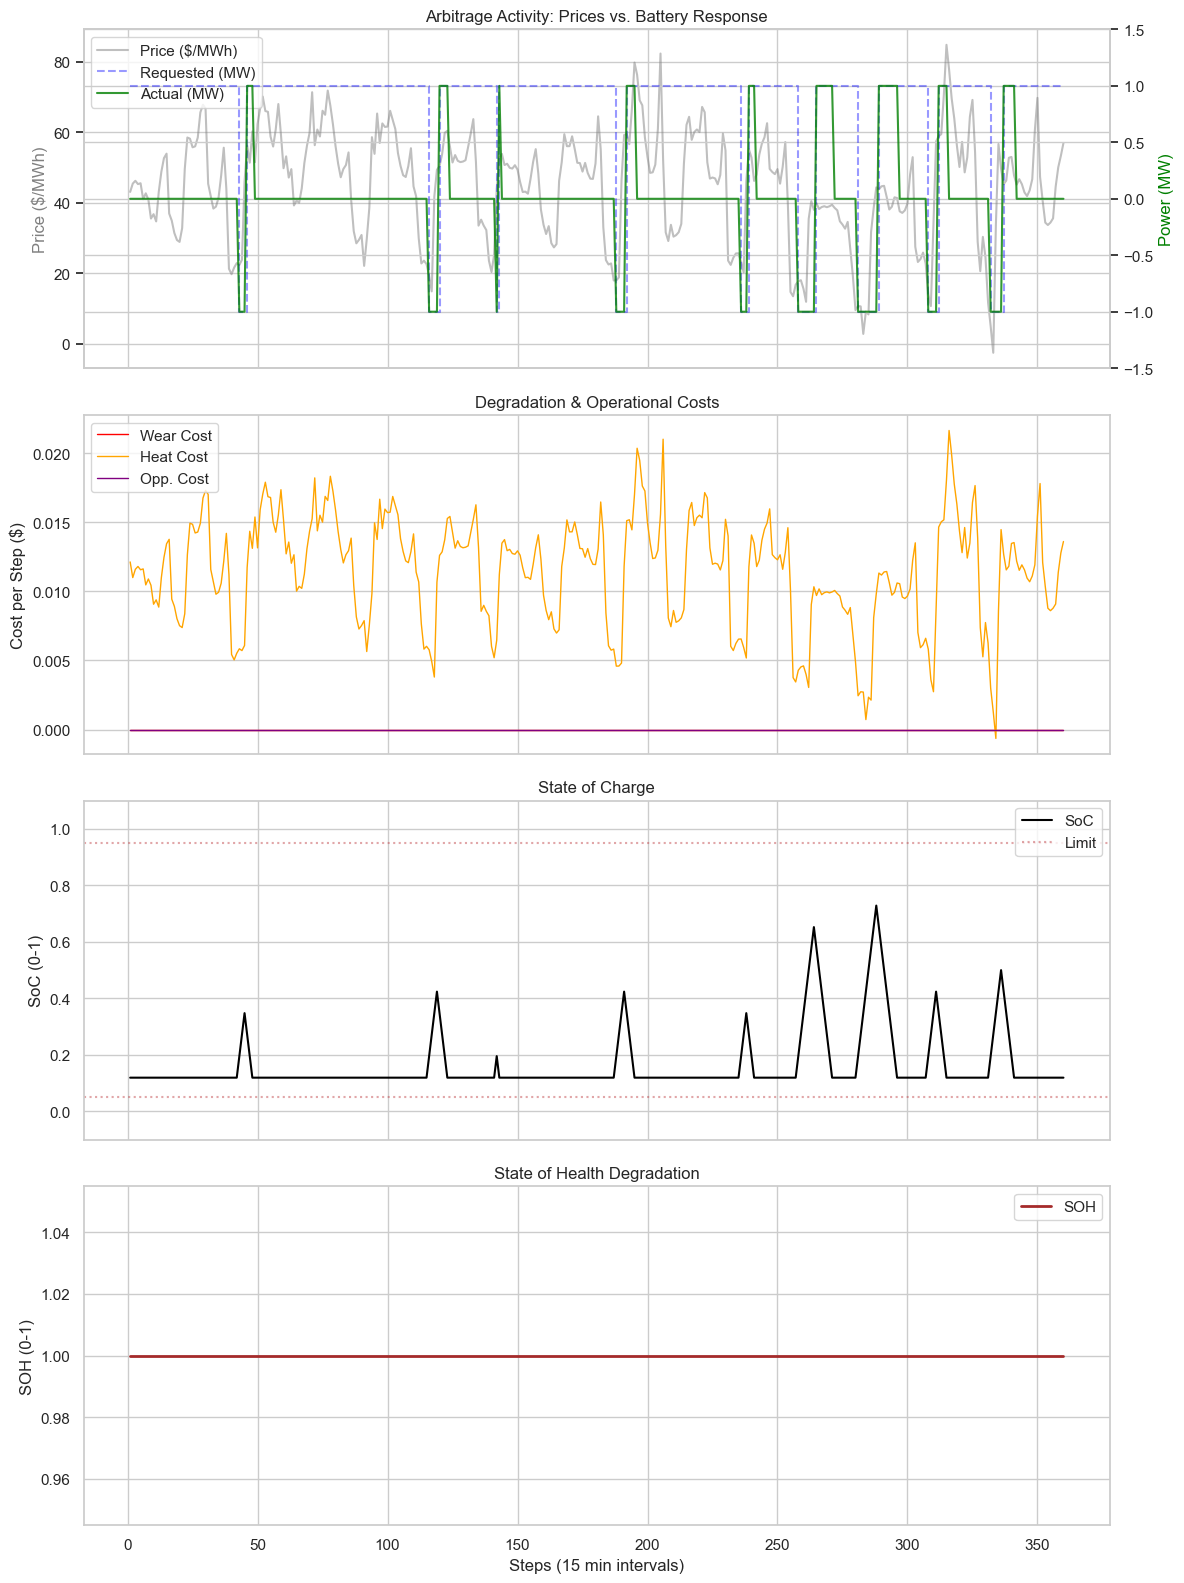

In [20]:

print("Generating Plots...")
sns.set_theme(style="whitegrid")

steps = np.array(history["step"])
prices = np.array(history["price"])
actions = np.array(history["action_mw"])
actuals = np.array(history["actual_mw"])

plot_limit = 24*15
s_slice = slice(0, plot_limit) if len(steps) > plot_limit else slice(0, len(steps))

fig, axes = plt.subplots(4, 1, figsize=(12, 16), sharex=True)

# Plot 1: Price vs Power
ax1 = axes[0]
ax1_right = ax1.twinx()
ln1 = ax1.plot(steps[s_slice], prices[s_slice], color='grey', alpha=0.5, label='Price ($/MWh)', linewidth=1.5)
ax1.set_ylabel("Price ($/MWh)", color='grey')
ln2 = ax1_right.step(steps[s_slice], actions[s_slice], color='blue', linestyle='--', alpha=0.4, label='Requested (MW)', where='post')
ln3 = ax1_right.plot(steps[s_slice], actuals[s_slice], color='green', alpha=0.8, label='Actual (MW)', linewidth=1.5)
ax1_right.set_ylabel("Power (MW)", color='green')
ax1_right.set_ylim(-1.5, 1.5)
lns = ln1 + ln2 + ln3
labs = [l.get_label() for l in lns]
ax1.legend(lns, labs, loc='upper left')
ax1.set_title("Arbitrage Activity: Prices vs. Battery Response")

# Plot 2: Costs
ax2 = axes[1]
ax2.plot(steps[s_slice], history["cost_wear"][s_slice], label='Wear Cost', color='red', linewidth=1)
ax2.plot(steps[s_slice], history["cost_heat"][s_slice], label='Heat Cost', color='orange', linewidth=1)
ax2.plot(steps[s_slice], history["cost_opp"][s_slice], label='Opp. Cost', color='purple', linewidth=1)
ax2.set_ylabel("Cost per Step ($)")
ax2.legend(loc='upper left')
ax2.set_title("Degradation & Operational Costs")

# Plot 3: SoC
ax3 = axes[2]
ax3.plot(steps[s_slice], history["soc"][s_slice], color='black', linewidth=1.5, label='SoC')
ax3.axhline(0.95, color='r', linestyle=':', alpha=0.5, label='Limit')
ax3.axhline(0.05, color='r', linestyle=':', alpha=0.5)
ax3.set_ylabel("SoC (0-1)")
ax3.set_ylim(-0.1, 1.1)
ax3.legend(loc='upper right')
ax3.set_title("State of Charge")

# Plot 4: SOH
ax4 = axes[3]
ax4.plot(steps[s_slice], history["soh"][s_slice], color='brown', linewidth=2, label='SOH')
ax4.set_ylabel("SOH (0-1)")
ax4.set_xlabel("Steps (15 min intervals)")
ax4.set_title("State of Health Degradation")
ax4.legend(loc='upper right')

plt.tight_layout()
plt.show()

### Performance

#### Model

In [ ]:
df4=pd.DataFrame(history)
df4["income"]=df4.actual_mw*df4.price
print("Total Income: ${:,.2f}".format(df4["income"].sum())) 

Total Income: $61,066.11


#### Perfect Foresight

In [ ]:
import cvxpy as cp

def optimal_dispatch(capacity_mwh, max_power_mw, price_series):
    T = len(price_series)

    p = cp.Variable(T)      # discharge (+) / charge (-)
    e = cp.Variable(T+1)    # energy state of charge

    constraints = []
    constraints += [e[0] == 0]
    constraints += [e[T] == 0]

    for t in range(T):
        constraints += [e[t+1] == e[t] - p[t]]

    constraints += [p <=  max_power_mw]
    constraints += [p >= -max_power_mw]
    constraints += [e >= 0]
    constraints += [e <= capacity_mwh]

    revenue = cp.sum(cp.multiply(price_series, p))
    problem = cp.Problem(cp.Maximize(revenue), constraints)

    problem.solve(solver=cp.OSQP)  # 👍 OSQP always available in Colab

    return np.array(p.value), float(revenue.value)

capacity_mwh = 10.0      # usable battery energy
max_power_mw = 1.0       # max charging or discharging

p_opt, revenue = optimal_dispatch(capacity_mwh, max_power_mw, df4.price)

print("Total Income: ${:,.2f}".format(revenue)) 


Total Income: $98,375.37


#### Time of the day prescheduled operation

In [68]:
def learn_hourly_operation_rule(time_series, price_series,
                                low_q=0.30, high_q=0.70):
    """
    Computes average price per hour-of-day and derives:
       - charge_hours  = hours where avg price is in the lowest quantile
       - discharge_hours = hours where avg price is in the highest quantile
    No perfect information; rule learned once from the full dataset.
    """

    df_tmp = pd.DataFrame({
        "time": pd.to_datetime(time_series),
        "price": price_series
    })
    df_tmp["hour"] = df_tmp["time"].dt.hour

    # average price by hour 0–23
    hourly_mean = df_tmp.groupby("hour")["price"].mean()

    # thresholds
    low_thr = hourly_mean.quantile(low_q)
    charge_hours = list(hourly_mean[hourly_mean <= low_thr].index)

    # pick same number of hours from the top
    num = len(charge_hours)
    high_sorted = hourly_mean.sort_values(ascending=False)
    discharge_hours = list(high_sorted.head(num).index)


    return charge_hours, discharge_hours, hourly_mean

def heuristic_dispatch_time_of_day_learned(
    time_series, price_series,
    capacity_mwh=2.0,
    max_power_mw=1.0,
    low_q=0.30, high_q=0.70
):
    """
    A time-of-day rule *learned from data*:
        - compute average price per hour
        - charge during historically cheap hours
        - discharge during historically expensive hours
        - idle otherwise
    """

    # --- learn rule ---
    charge_hours, discharge_hours, hourly_mean = learn_hourly_operation_rule(
        time_series, price_series, low_q, high_q
    )

    # --- battery simulation ---
    prices = np.asarray(price_series)
    times = pd.to_datetime(time_series)
    hours = times.dt.hour.values
    T = len(prices)

    p = np.zeros(T)
    soc = np.zeros(T+1)

    for t in range(T):
        h = hours[t]
        soc_now = soc[t]

        max_discharge = min(max_power_mw, soc_now)
        max_charge    = min(max_power_mw, capacity_mwh - soc_now)

        if h in charge_hours:
            p[t] = -max_charge
        elif h in discharge_hours:
            p[t] = +max_discharge
        else:
            p[t] = 0.0

        soc[t+1] = soc[t] - p[t]
        soc[t+1] = max(0, min(capacity_mwh, soc[t+1]))

    revenue = float(np.sum(prices * p))

    return p, soc, revenue, charge_hours, discharge_hours, hourly_mean

p_tod, soc_tod, rev_tod, charge_hours, discharge_hours, hourly_mean = (
    heuristic_dispatch_time_of_day_learned(
        train_df.iloc[:-1]["Date"], df4.price,
        capacity_mwh=10.0,
        max_power_mw=1.0,
        low_q=0.3,      # bottom 30% hours = charge
        high_q=0.6      # top 30% hours = discharge
    )
)

print("Learned charge hours:    ", charge_hours)
print("Learned discharge hours: ", discharge_hours)
print("Total Income: ${:,.2f}".format(rev_tod)) 


Learned charge hours:     [11, 12, 13, 14, 15, 16, 17]
Learned discharge hours:  [0, 8, 23, 21, 1, 22, 2]
Total Income: $68,784.76
